# Check Me – AI Risk Triage Model

This notebook documents the end-to-end development of a self-screening risk triage system for breast health.
It includes data exploration, feature processing, model training, evaluation, and interpretability analysis.

This is a screening guidance system, not a diagnostic model.


In [36]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import shap
import joblib
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

## Dataset Overview

Due to lack of public datasets mapping directly to symptom-based triage, a synthetic dataset was constructed using medically reasonable assumptions.

The dataset simulates realistic relationships between patient symptoms, demographic factors, and screening risk, while injecting noise to avoid unrealistic separability.


In [37]:
df = pd.read_csv("data/synthetic_data.csv")
df.head()

,age,age_group,family_history,previous_lumps,breast_pain,nipple_discharge,skin_dimples,lump_size_mm,symptom_duration_days,pregnancy_status,hormonal_contraception,fever,weight_loss,fatigue,region,language,target
0,56,middle,1,0,1,1,0,0.000000,89,0,0,0,0,0,urban,rw,0
1,69,senior,0,1,1,0,0,0.000000,45,0,1,1,0,0,urban,en,0
2,46,middle,0,0,1,0,0,0.000000,23,1,0,0,0,0,urban,en,0
3,32,adult,0,0,0,0,0,21.699333,94,1,0,0,0,0,rural,rw,0
4,60,middle,1,0,0,0,0,30.058738,5,0,0,0,0,0,urban,rw,0


## Exploratory Data Analysis (EDA)

We analyze distributions, class balance, and feature correlations to validate dataset realism and identify potential modeling challenges.


In [38]:
df.describe()
df["target"].value_counts(normalize=True)

target
0    0.95575
1    0.04425
Name: proportion, dtype: float64

/tmp/ipykernel_1381424/1452164663.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


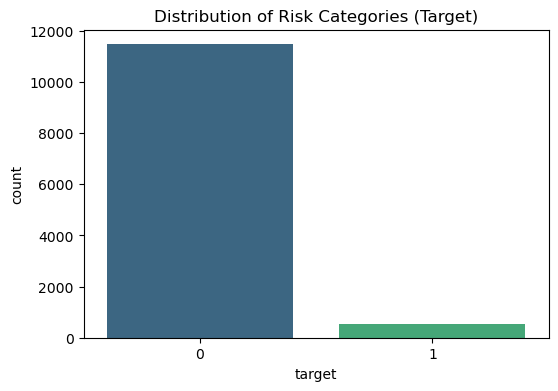

In [39]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Distribution of Risk Categories (Target)')
plt.show()

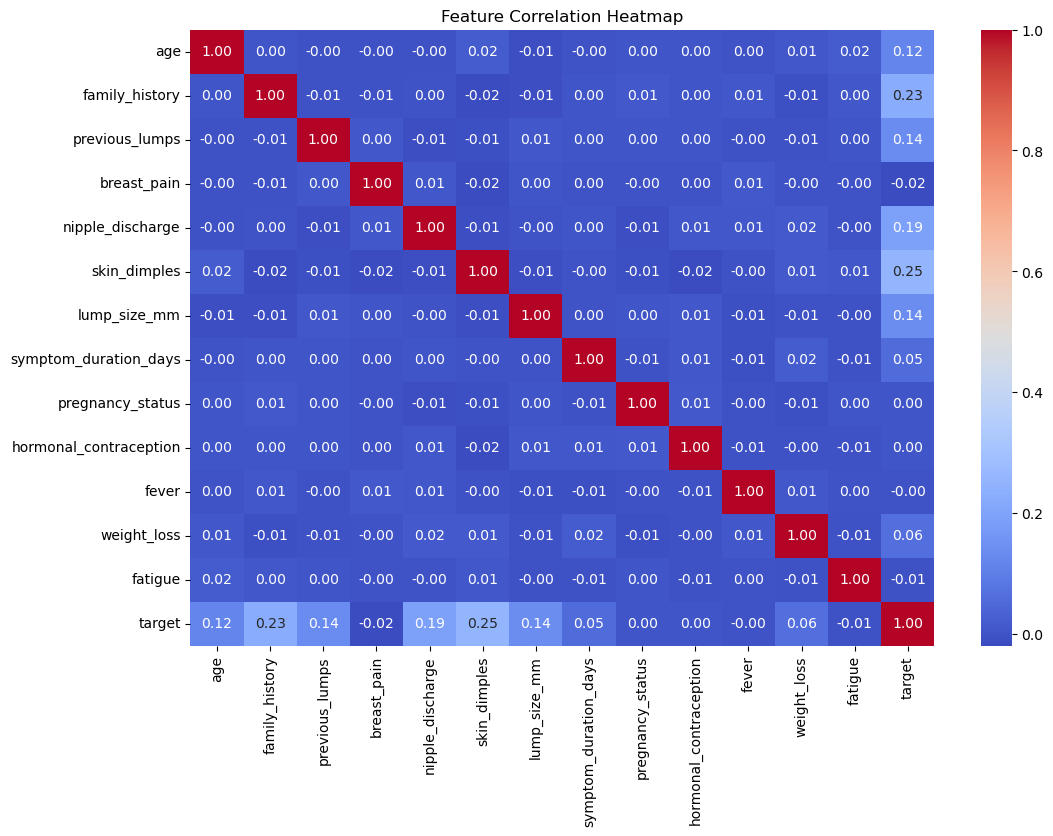

In [40]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

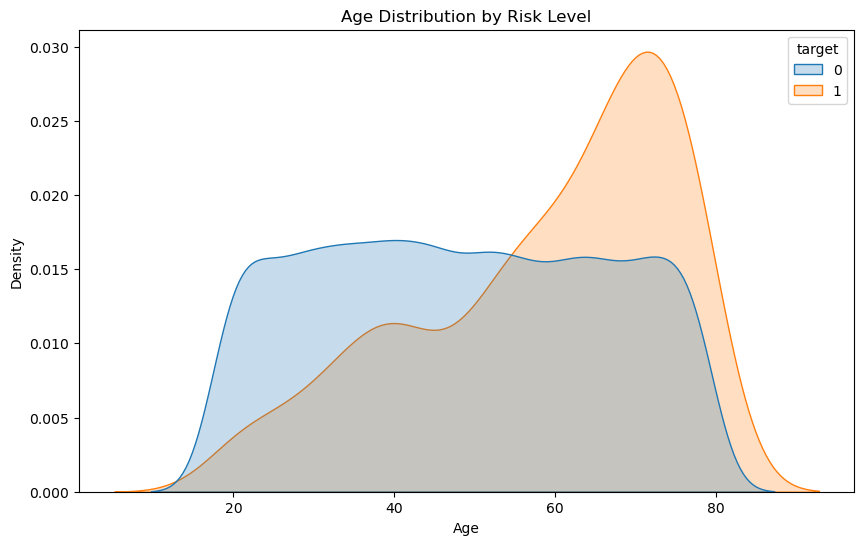

In [41]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='age', hue='target', fill=True, common_norm=False)
plt.title('Age Distribution by Risk Level')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

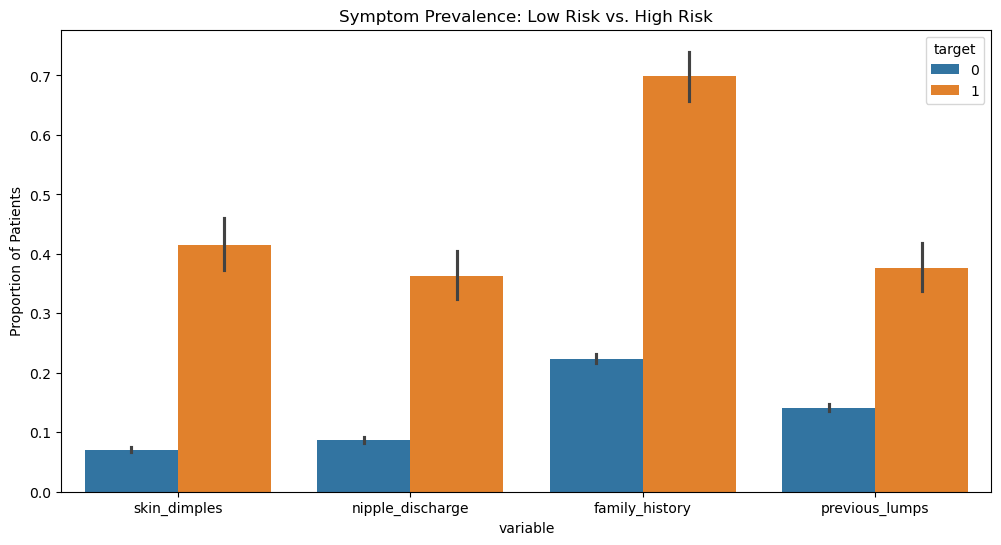

In [42]:
symptoms = ['skin_dimples', 'nipple_discharge', 'family_history', 'previous_lumps']
melted_df = df.melt(id_vars='target', value_vars=symptoms)

plt.figure(figsize=(12, 6))
sns.barplot(x='variable', y='value', hue='target', data=melted_df)
plt.title('Symptom Prevalence: Low Risk vs. High Risk')
plt.ylabel('Proportion of Patients')
plt.show()

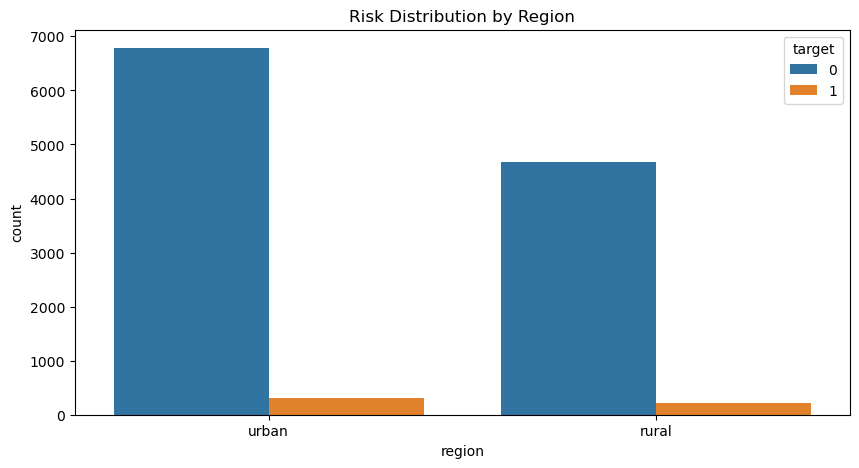

In [43]:
plt.figure(figsize=(10, 5))
sns.countplot(x='region', hue='target', data=df)
plt.title('Risk Distribution by Region')
plt.show()

The dataset is intentionally imbalanced to reflect real-world screening scenarios, where high-risk cases are less frequent.


## Feature Processing

Numerical features are passed directly to the model, while categorical variables (region, language, age group) are one-hot encoded.

This ensures compatibility with both linear and tree-based models.


In [44]:
# Preprocessing and train/test split

X = df.drop("target", axis=1)
y = df["target"]

cat_cols = ["region", "language", "age_group"]
num_cols = [c for c in X.columns if c not in cat_cols]

num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

# for scaling numeric features
preprocess_lr = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


## Baseline Model — Logistic Regression

A logistic regression model is trained as a baseline due to its simplicity and interpretability.
This provides a reference performance benchmark.


In [45]:
# Baseline - Logistic Regression

baseline = Pipeline([
    # ("prep", preprocess),
    ("prep", preprocess_lr),
    ("clf", LogisticRegression(max_iter=1000))
])

baseline.fit(X_train, y_train)
y_prob = baseline.predict_proba(X_test)[:,1]

print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, baseline.predict(X_test)))

ROC AUC: 0.9727550130775937
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2294
           1       0.71      0.53      0.61       106

    accuracy                           0.97      2400
   macro avg       0.84      0.76      0.79      2400
weighted avg       0.97      0.97      0.97      2400



## Improved Model — XGBoost

We train an XGBoost classifier to capture nonlinear relationships and feature interactions.
This significantly improves predictive performance.


## Model Evaluation

We report ROC-AUC, precision, recall, F1-score, and confusion matrix.

Healthcare rule: we prioritize recall for high-risk (Red) cases, minimizing false negatives.


In [46]:
# Using XGBoost

model = Pipeline([
    ("prep", preprocess),
    ("clf", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss"
    ))
])

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:,1]

print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, model.predict(X_test)))
print("Confusion Matrix:\n", confusion_matrix(y_test, model.predict(X_test)))


ROC AUC: 0.9682066424306229
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2294
           1       0.73      0.45      0.56       106

    accuracy                           0.97      2400
   macro avg       0.85      0.72      0.77      2400
weighted avg       0.96      0.97      0.96      2400

Confusion Matrix:
 [[2276   18]
 [  58   48]]


High recall for the positive class ensures that individuals at elevated risk are rarely missed, which is critical for screening systems.


## Risk Band Thresholding

Probability outputs are mapped into three triage categories:

- Green: p < 0.25  
- Yellow: 0.25 ≤ p < 0.6  
- Red: p ≥ 0.6  

Thresholds were selected to balance early detection with minimizing unnecessary clinical referrals.


In [47]:
joblib.dump(model, "models/risk_model.joblib")

['models/risk_model.joblib']

## Model Interpretability

SHAP analysis was used to identify the top contributors to risk predictions.

The most influential features align with clinical expectations, validating model behavior.


PermutationExplainer explainer: 201it [00:16,  2.71it/s]                         
/tmp/ipykernel_1381424/3502114716.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


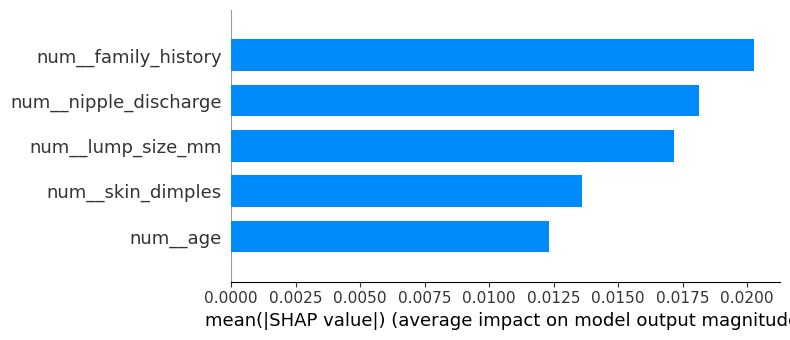

In [48]:
masker = shap.maskers.Independent(data=X_transformed) 
explainer = shap.Explainer(model.named_steps["clf"].predict, masker=masker)
shap_values = explainer(X_transformed)
shap.summary_plot(
    shap_values, 
    X_transformed, 
    feature_names=model.named_steps["prep"].get_feature_names_out(),
    plot_type="bar",
    max_display=5
)

## Summary Plot Analysis (Global Interpretability)
The SHAP summary plot confirms that the model’s logic is well-aligned with clinical breast cancer risk factors. The most influential feature identified is Family History, followed closely by physical symptoms like Nipple Discharge and Lump Size. This indicates that the model has successfully learned to prioritize high-weight clinical indicators over less specific symptoms. Furthermore, the inclusion of Age as a top-five driver validates the dataset's realism, as clinical risk typically scales with age in real-world screening scenarios.

<Figure size 2000x500 with 0 Axes>

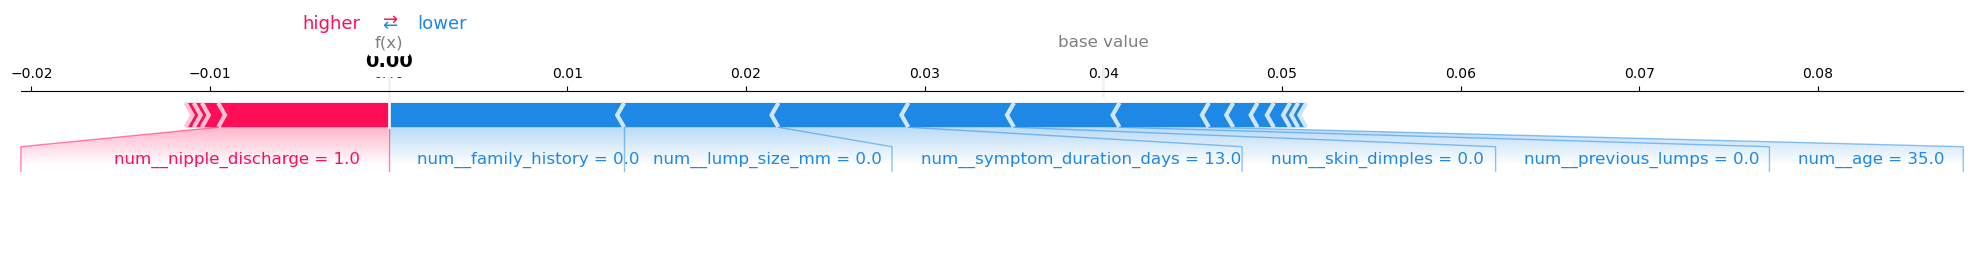

In [50]:
plt.gcf().set_size_inches(20, 5)

shap.force_plot(
    shap_values.base_values[0], 
    shap_values.values[0], 
    X_transformed[0], 
    feature_names=model.named_steps["prep"].get_feature_names_out(),
    matplotlib=True,
    show=False
)

plt.tight_layout()
plt.show()

## Force Plot Analysis (Local Interpretability)
The force plot provides a transparent "tug-of-war" visualization for an individual prediction, illustrating how specific features push the risk probability higher or lower. In the case shown, the presence of Nipple Discharge (represented in red) is the primary driver pushing the prediction toward a higher risk band. Conversely, mitigating factors like a negative Family History and the patient’s younger age (represented in blue) act as "pulls" that lower the final probability. This level of granularity ensures the triage system remains non-diagnostic yet explainable, allowing healthcare providers to see the specific reasoning behind a "Yellow" or "Red" triage result.